# Stacking

This notebook demonstrates how to perform image stacking using the EZPhot package. Image stacking is a fundamental technique in astronomical image processing that combines multiple exposures to improve signal-to-noise ratio and reduce noise.

## 1. Load Data

- Use the `DataBrowser` class to query and filter images
- Load science images for processing

> **💡 Optional Tip**: The `SDTDataQuerier` class provides methods to sync data from a central database to your local workspace, making it easy to work with large astronomical datasets.

<br><br>

### 🔍 1.1. Sync the data with SDTDataQuerier (Optional)


In [1]:
# If you connected the database, you can easily sync the data from the database. 
from ezphot.utils import SDTDataQuerier
sdtquery = SDTDataQuerier()
sdtquery.help()
target_name = 'T00528'

Help for SDTDataQuerier


Public methods:
- show_obsdestdata(foldername: str, show_only_numbers: bool = False, pattern: str = '*.fits')
- show_obsdestfolder(folder_key: str = '*')
- show_obssourcedata(foldername: str, show_only_numbers: bool = False, pattern: str = '*.fits')
- show_obssourcefolder(folder_key: str = '*')
- show_scidestdata(targetname: str, show_only_numbers: bool = False, key: str = 'filter', pattern: str = '*.fits')
- show_scisourcedata(targetname: str, show_only_numbers: bool = False, key: str = 'filter', file_pattern: str = '*.fits')
- show_scisourcefolder(folder_key: str = '*')
- sync_obsdata(foldername: str, file_pattern: str = '*.fits', ignore_exists: bool = True)
- sync_scidata(targetname: str, file_pattern: str = '*.fits', ignore_exists: bool = True)


In [ ]:
# sync_scidata method will run multiple rsync between Science Source directory and destination directory.
print('Source directory:', sdtquery.helper.config['SDTDATA_SCISOURCEDIR'])
print('Target directory:', sdtquery.helper.config['SDTDATA_SCIDESTDIR'])
sdtquery.sync_scidata(
    targetname = target_name,
    file_pattern = '*.fits',
    ignore_exists = True
)

**🔄 Sync Progress**: The rsync process copies FITS files from the source directory to your local destination directory.


<br><br>

###  1.2. Query Data with DataBrowser

The `DataBrowser` class allows us to query and filter our synced data. Here we'll explore the available keys and their values to understand what data we have access to.


In [2]:
# Then, you can query your data with DataBrowser class. 
# Since the data is copied to your private directory (['SCIDATA_SCIDESTDIR'](e.g. ~/ezphot/data/scidata by default) in configuration), you can use it as your own data. 
# You can also use it as a context for ezphot. 

from ezphot.utils import DataBrowser
dbrowser = DataBrowser('scidata')
# You can query the data with the below keys.
for key, value in dbrowser.keys.items():
    print(key, value)

observatory {'7DT'}
telkey {'7DT_C361K_HIGH_1x1'}
objname {'T23189', 'T25043', 'T00596', 'T13825', 'T02874', 'T03198', 'T14574', 'T12053', 'T02595', 'T00405', 'T13722', 'T00595', 'T11112', 'T00577', 'T13559', 'T13072', 'T04803', 'T14479', 'T09373', 'T13824', 'T03704', 'T07169', 'T01701', 'T23736', 'T01428', 'T00463', 'T22614', 'T12732', 'T21742', 'T03209', 'T09040', 'T24804', 'T02452', 'T09041', 'T14354', 'T00465', 'T07128', 'T01933', 'T13558', 'T24558', 'T11971', 'T24225', 'T02072', 'T00311', 'T05281', 'T24735', 'T03458', 'T11704', 'T11764', 'T11621', 'T13257', 'T23968', 'T14918', 'T09543', 'T21343', 'T23132', 'T01501', 'T14712', 'T03051', 'T20716', 'T03580', 'T13496', 'T03377', 'T13823', 'T13707', 'T05004', 'T19684', 'T23488', 'T01580', 'T00486', 'T11622', 'T04237', 'T23977', 'T03898', 'T01161', 'T22924', 'T15696', 'T13541', 'T12025', 'T25337', 'T13520', 'T05018', 'T11148', 'T09370', 'T02349', 'T14943', 'T02535', 'T06467', 'T10228', 'T24028', 'T21733', 'T01505', 'T13557', 'T25303', '

Let's filter our data to find specific images. We'll search for:
- **Target**: T00528
- **Filter**: m600
- **Pattern**: Files ending with `*100.fits`


In [3]:
dbrowser.objname = 'T00528'
dbrowser.filter = 'm600'
dbrowser.search('*100.fits', return_type = 'path')

[INFO] Found 90 files matching '/home/hhchoi1022/ezphot/data/scidata/*/*/T00528/*/m600/*100.fits'


['/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT14/m600/calib_7DT14_T00528_20250906_025855_m600_100.fits',
 '/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT14/m600/calib_7DT14_T00528_20250903_234441_m600_100.fits',
 '/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT14/m600/calib_7DT14_T00528_20250902_072423_m600_100.fits',
 '/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT14/m600/calib_7DT14_T00528_20250831_235542_m600_100.fits',
 '/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT14/m600/calib_7DT14_T00528_20250902_074036_m600_100.fits',
 '/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT14/m600/calib_7DT14_T00528_20250903_235531_m600_100.fits',
 '/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT14/m600/calib_7DT14_T00528_20250904_234659_m600_100.fits',
 '/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT14/m600/cal

In [4]:
# If you wish to get the ScienceImage object, 
target_imgset = dbrowser.search('*100.fits', return_type = 'science')
target_imglist = target_imgset.target_images
# If you wish to get the metadata table from the keys, 
metadata_table = dbrowser.search('*100.fits', return_type = 'imginfo')

[INFO] Found 90 files matching '/home/hhchoi1022/ezphot/data/scidata/*/*/T00528/*/m600/*100.fits'


Loading Science Images: 100%|██████████| 90/90 [00:01<00:00, 56.88it/s]


[INFO] Found 90 files matching '/home/hhchoi1022/ezphot/data/scidata/*/*/T00528/*/m600/*100.fits'
Loaded 90 FITS files from /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT14/m600
Total FITS files combined: 90


In [5]:
metadata_table

file,altitude,azimuth,ccd-temp,gain,filter,imgtype,exptime,obsdate,locdate,jd,mjd,binning,object,objctid,obsmode,specmode,note,telescop
str126,str32,str32,str32,str21,str4,str5,str32,str23,str23,str32,str32,str21,str6,str32,str4,str7,str9,str5
/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT14/m600/calib_7DT14_T00528_20250906_025855_m600_100.fits,43.226146,177.841909,-10.1,2750,m600,LIGHT,100.0,2025-09-06T02:58:55.000,2025-09-05 22:58:55.000,2460924.624247685,60924.124247685184,1,T00528,1d2f12912f6841dc9ad12497eef6268e,Spec,specall,S250830bp,7DT14
/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT14/m600/calib_7DT14_T00528_20250903_234441_m600_100.fits,36.655996,166.440658,-10.1,2750,m600,LIGHT,100.0,2025-09-03T23:44:41.000,2025-09-03 19:44:41.000,2460922.489363426,60921.98936342593,1,T00528,1d2f12912f6841dc9ad12497eef6268e,Spec,specall,S250830bp,7DT14
/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT14/m600/calib_7DT14_T00528_20250902_072423_m600_100.fits,37.102087,193.288747,-10.1,2750,m600,LIGHT,100.0,2025-09-02T07:24:23.000,2025-09-02 03:24:23.000,2460920.8085995372,60920.308599537035,1,T00528,1d2f12912f6841dc9ad12497eef6268e,Spec,specall,S250830bp,7DT14
/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT14/m600/calib_7DT14_T00528_20250831_235542_m600_100.fits,36.617178,166.418143,-10.0,2750,m600,LIGHT,100.0,2025-08-31T23:55:42.000,2025-08-31 19:55:42.000,2460919.497013889,60918.99701388889,1,T00528,1d2f12912f6841dc9ad12497eef6268e,Spec,specall,S250830bp,7DT14
/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT14/m600/calib_7DT14_T00528_20250902_074036_m600_100.fits,36.283207,193.763747,-10.1,2750,m600,LIGHT,100.0,2025-09-02T07:40:36.000,2025-09-02 03:40:36.000,2460920.819861111,60920.319861111115,1,T00528,1d2f12912f6841dc9ad12497eef6268e,Spec,specall,S250830bp,7DT14
/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT14/m600/calib_7DT14_T00528_20250903_235531_m600_100.fits,37.198191,166.77371,-10.1,2750,m600,LIGHT,100.0,2025-09-03T23:55:31.000,2025-09-03 19:55:31.000,2460922.496886574,60921.996886574074,1,T00528,1d2f12912f6841dc9ad12497eef6268e,Spec,specall,S250830bp,7DT14
/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT14/m600/calib_7DT14_T00528_20250904_234659_m600_100.fits,36.969771,166.628158,-10.1,2750,m600,LIGHT,100.0,2025-09-04T23:46:59.000,2025-09-04 19:46:59.000,2460923.4909606483,60922.990960648145,1,T00528,1d2f12912f6841dc9ad12497eef6268e,Spec,specall,S250830bp,7DT14
/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT14/m600/calib_7DT14_T00528_20250902_073848_m600_100.fits,36.375758,193.714859,-10.0,2750,m600,LIGHT,100.0,2025-09-02T07:38:48.000,2025-09-02 03:38:48.000,2460920.818611111,60920.31861111111,1,T00528,1d2f12912f6841dc9ad12497eef6268e,Spec,specall,S250830bp,7DT14
/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT14/m600/calib_7DT14_T00528_20250906_235138_m600_100.fits,37.585349,167.040065,-10.0,2750,m600,LIGHT,100.0,2025-09-06T23:51:38.000,2025-09-06 19:51:38.000,2460925.4941898147,60924.99418981482,1,T00528,1d2f12912f6841dc9ad12497eef6268e,Spec,specall,S250830bp,7DT14


<br><br>
<br><br>

## 2. Check Your Images

Now that we have loaded our data, let's inspect the images to understand their properties and quality:

> **Memory Warning**: Astronomical images can be large. Always use `ScienceImage.clear()` to free memory when you're done with an image.

(<Figure size 800x600 with 2 Axes>,
 <WCSAxes: title={'center': 'calib_7DT14_T00528_20250906_025855_m600_100.fits'}>)

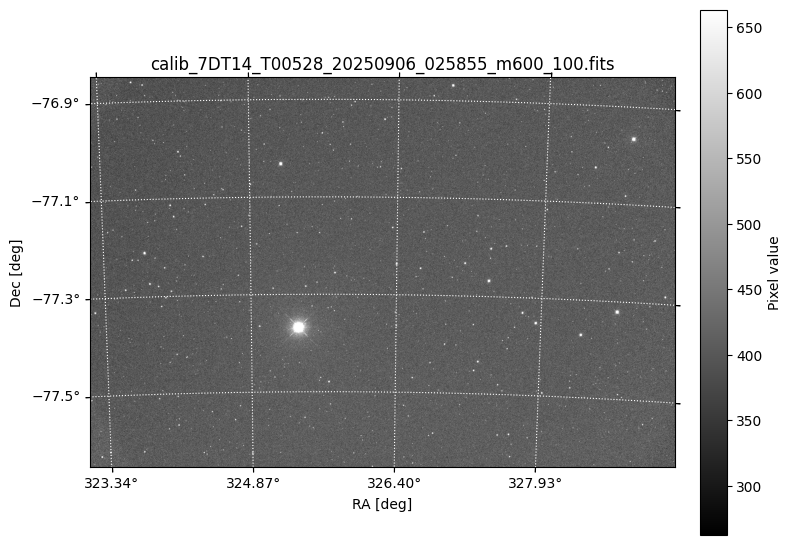

In [6]:
target_img = target_imglist[0]
target_img.show('coord')

In [7]:
# [CAUTION] For memory management, NOTE the below example.
# When you run any functions that load the data, all data are stored in the memory (data_load = True).
target_img

ScienceImage(
  is_exists   = True,
  is_saved    = True,
  data_load   = True,
  header_load = True,
  imgtype     = LIGHT,
  exptime     = 100.0,
  filter      = m600,
  path        = /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT14/m600/calib_7DT14_T00528_20250906_025855_m600_100.fits,
  savedir     = /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT14/m600
)

Use `ScienceImage.clear()` to free memory when you're done with an image:

In [8]:
#To clear the memory, run ScienceImage.clear()
target_img.clear()
target_img

Cleared data and/or header from memory.


ScienceImage(
  is_exists   = True,
  is_saved    = True,
  data_load   = False,
  header_load = True,
  imgtype     = LIGHT,
  exptime     = 100.0,
  filter      = m600,
  path        = /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT14/m600/calib_7DT14_T00528_20250906_025855_m600_100.fits,
  savedir     = /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT14/m600
)

In [9]:
# You can check the image with ds9 if X11 forward is available (via SSH)
target_img.run_ds9()

Running "ds9 -scalemode zscale -scale lock yes -frame lock image /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT14/m600/calib_7DT14_T00528_20250906_025855_m600_100.fits &" in the terminal...


bash: cannot set terminal process group (2263633): Inappropriate ioctl for device
bash: no job control in this shell


<br><br>
<br><br>

## 3. Background Estimation

Background estimation is crucial for accurate photometry and image analysis. Here we are going to repeat the procedure in :doc:`example/backgroundestimation`.

- **Estimate background** using the SEP (Source Extractor Python) algorithm
- **Apply source masking** to improve background estimation

> **Science Note**: Background estimation removes sky brightness and instrumental effects, revealing the true astronomical sources in your images.

<br><br>

### 3.1. Background estimation


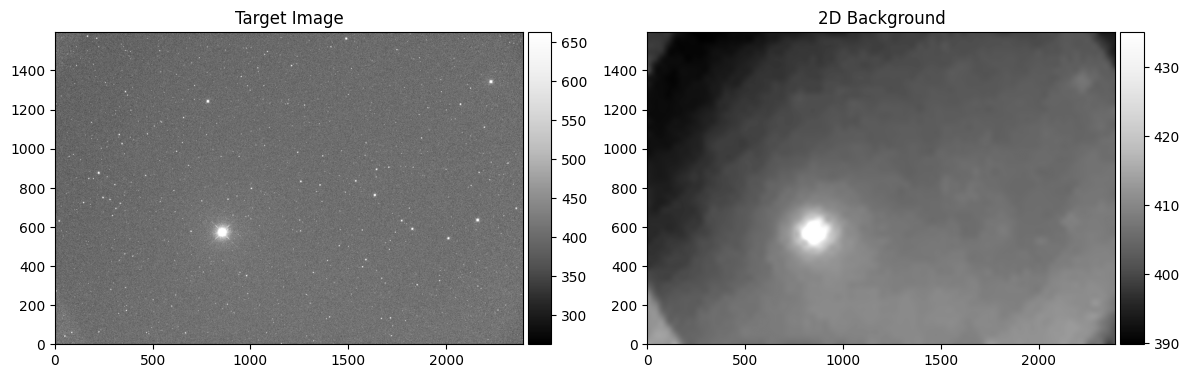

Cleared data and header from memory.


In [10]:
# Calculate the background map
target_bkg = target_img.calculate_bkg(
    target_srcmask = None,
    target_ivpmask = None,
    is_2D_bkg = True,
    box_size = 128,
    filter_size = 3,
    save = False,
    verbose = True,
    visualize = True
)
# Clear the memory
target_bkg.clear(verbose = True)

<br><br>

### 3.2. Advanced Background Estimation

Sometimes the background model may include real sources like saturated stars or extended objects. In such cases, you can apply source masks to improve the background estimation.

> **💡 Pro Tip**: Source masking helps create cleaner background models by excluding bright objects that could bias the background calculation.


#### 3.2.1. Automatic Source Mask Generation 

Masking source... [sigma = 5.0, mask_radius_factor = 2]


[1] 3275150
application-specific initialization failed: no display name and no $DISPLAY environment variable
Unable to initialize window system.


2948 non-saturated, 13 saturated sources
2961 sources masked.


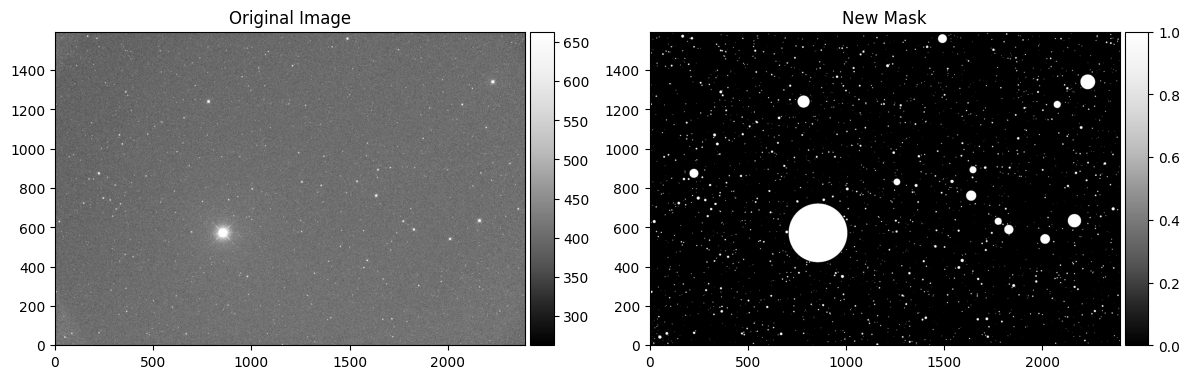

In [11]:
target_srcmask = target_img.calculate_sourcemask(
    sigma = 5.0,
    mask_radius_factor = 2,
    saturation_level = 50000,
    save = False,
    verbose = True,
    visualize = True,
    save_fig = False
)

#### 3.2.2. Re-generation of Background Map with Source Mask


External mask is loaded.


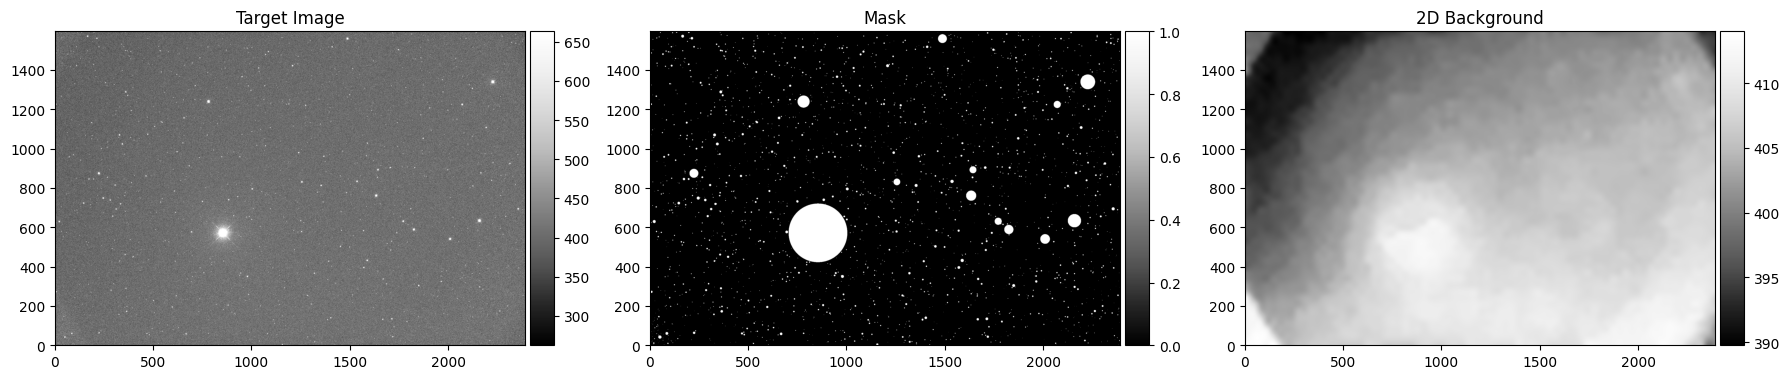

In [12]:
target_bkg_with_srcmask = target_img.calculate_bkg(
    target_srcmask = target_srcmask,
    target_ivpmask = None,
    is_2D_bkg = True,
    box_size = 128,
    filter_size = 3,
)

In [13]:
# Write and clear the memory
target_srcmask.write()
target_bkg_with_srcmask.write()
target_srcmask.clear()
target_bkg_with_srcmask.clear()

# After writing the files, you can access to the files as attributes of the ScienceImage object.
print(target_img.bkgmap)
print(target_img.sourcemask)

Saved: /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT14/m600/calib_7DT14_T00528_20250906_025855_m600_100.fits.srcmask
Saved: /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT14/m600/calib_7DT14_T00528_20250906_025855_m600_100.fits.bkgmap
Cleared data and header from memory.
Cleared data and header from memory.
Background(
  is_exists   = True,
  is_saved    = True,
  data_load   = False,
  header_load = True,
  path        = /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT14/m600/calib_7DT14_T00528_20250906_025855_m600_100.fits.bkgmap,
  savedir     = /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT14/m600
)
Mask(
  is_exists   = True,
  is_saved    = True,
  data_load   = False,
  header_load = True,
  path        = /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT14/m600/calib_7DT14_T00528_20250906_025855_m600_100.fits.srcmask,
  savedir     = /home/hhchoi1022/ezphot/data/sci

In [14]:
# Run for all target_imglist with multiprocessing
from multiprocessing import Pool
from tqdm import tqdm

def calculate_bkg(target_img):    
    target_srcmask = target_img.calculate_sourcemask(   
        sigma = 5.0,
        mask_radius_factor = 2,
        saturation_level = 50000,
        save = True,
        verbose = False,
        visualize = False,
        save_fig = False
    )
    target_img.calculate_bkg(
        target_srcmask = target_srcmask,
        target_ivpmask = None,
        is_2D_bkg = True,
        box_size = 128,
        filter_size = 3,
        save = True,
        verbose = False,
        visualize = False,
        save_fig = False
    )    
                
    target_srcmask.clear(verbose = False)
    target_bkg.clear(verbose = False)
    
with Pool(processes = 16) as pool:
    # Use tqdm with imap to show progress
    list(tqdm(pool.imap(calculate_bkg, target_imglist), 
              total=len(target_imglist), 
              desc="Calculating backgrounds"))


Calculating backgrounds: 100%|██████████| 90/90 [05:48<00:00,  3.87s/it]


<br><br>
<br><br>

## 4. Image stacking

Image stacking is possible with Stack class in ezphot. There are multiple options available before stacking

- **Background subtraction** (when target_bkglist is not None)
- **Zeropoint scaling** to match the level of flux between multiple images (when scale == True, ZP_key must exist in the header. To update ZP information, run photometriccalibration before this process)
- **Image convolution** to match the PSF size of multiple images (when convolve == True, seeing_key must exist in the header. To update SEEING information, run photometriccalibration before this process)

> **Science Note**: You can also stack Background RMS map by target_bkgrmslist parameters. 

<br><br>

### 4.1. Image stacking

In [15]:
from ezphot.methods import Stack

stacker = Stack()
stacker.help()

Help for Stack


Public methods:
- match_seeing(target_imglist: List[Union[ezphot.imageobjects.scienceimage.ScienceImage, ezphot.imageobjects.calibrationimage.CalibrationImage]], target_errormaplist: Optional[List[ezphot.imageobjects.errormap.Errormap]] = None, target_bkglist: Optional[List[ezphot.imageobjects.background.Background]] = None, seeing_key: str = 'SEEING', kernel: str = 'gaussian', save: bool = False, overwrite: bool = False, visualize: bool = True, verbose: bool = True, **kwargs)
- match_zeropoints(target_imglist: List[Union[ezphot.imageobjects.scienceimage.ScienceImage, ezphot.imageobjects.calibrationimage.CalibrationImage]], target_errormaplist: Optional[List[ezphot.imageobjects.errormap.Errormap]] = None, method: str = 'median', zp_key: str = 'ZP_APER_1', save: bool = False, overwrite: bool = False, verbose: bool = True, n_proc: int = 8, **kwargs)
- select_quality_images(target_imglist: Union[List[ezphot.imageobjects.scienceimage.ScienceImage], List[ezphot.imageobjects

In [16]:
target_imglist = target_imgset.target_images
target_bkglist = target_imgset.bkgmap
stacked_img, _ = stacker.stack_multiprocess(
    target_imglist = target_imglist,
    target_bkglist = target_bkglist,
    n_proc = 16,
    scale = False,
    convolve = False,
    save = True,
    verbose = False,
)

Combining...: 100%|██████████████████████████████████████████████| 16/16 [02:15]


(<Figure size 800x600 with 2 Axes>,
 <Axes: title={'center': 'calib_7DT14_T00528_20250906_025855_m600_100.com.fits'}, xlabel='X pixel', ylabel='Y pixel'>)

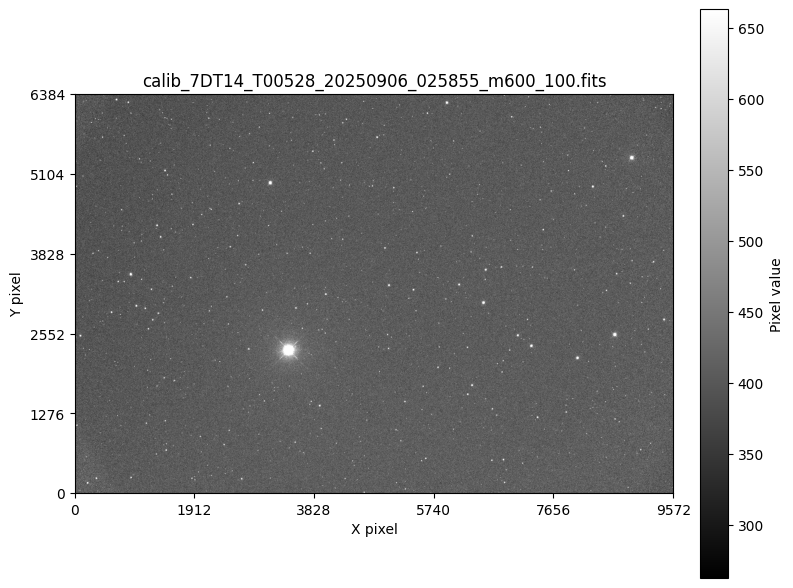

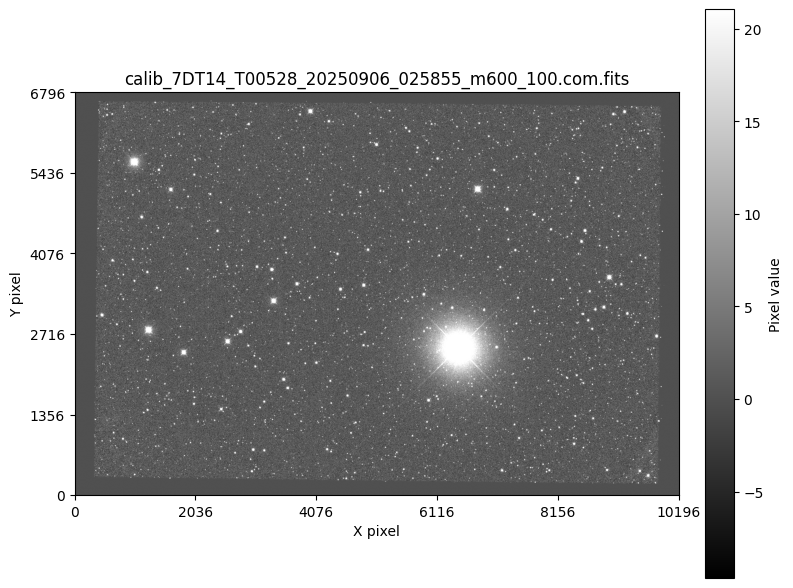

In [17]:
target_img.show()
stacked_img.show()

<br><br>

### 4.2. Image and Background RMS stacking 

In [18]:
from multiprocessing import Pool
from tqdm import tqdm
from ezphot.methods import Preprocess
preprocessor = Preprocess()
def calculate_bkgrms(target_img):
    mbias = preprocessor.get_masterframe_from_image(target_img, 'BIAS', 60)[0]
    mdark = preprocessor.get_masterframe_from_image(target_img, 'DARK', 60)[0]
    mflat = preprocessor.get_masterframe_from_image(target_img, 'FLAT', 60)[0]
    target_bkgrms = target_img.calculate_bkgrms_from_propagation(
        target_bkg = target_img.bkgmap,
        mbias = mbias,
        mdark = mdark,
        mflat = mflat,
        mflaterr = None,
        save = True,
        verbose = False,
        visualize = False,
        save_fig = False
    )
    target_bkgrms.clear(verbose = False)
    mbias.clear(verbose = False)
    mdark.clear(verbose = False)
    mflat.clear(verbose = False)

with Pool(processes = 16) as pool:
    # Use tqdm with imap to show progress
    target_bkgrmslist = list(tqdm(pool.imap(calculate_bkgrms, target_imglist), 
                                  total=len(target_imglist), 
                                  desc="Calculating background RMS"))

Calculating background RMS: 100%|██████████| 90/90 [02:36<00:00,  1.74s/it]


In [19]:
from ezphot.methods import Stack

stacker = Stack()
stacker.help()

Help for Stack


Public methods:
- match_seeing(target_imglist: List[Union[ezphot.imageobjects.scienceimage.ScienceImage, ezphot.imageobjects.calibrationimage.CalibrationImage]], target_errormaplist: Optional[List[ezphot.imageobjects.errormap.Errormap]] = None, target_bkglist: Optional[List[ezphot.imageobjects.background.Background]] = None, seeing_key: str = 'SEEING', kernel: str = 'gaussian', save: bool = False, overwrite: bool = False, visualize: bool = True, verbose: bool = True, **kwargs)
- match_zeropoints(target_imglist: List[Union[ezphot.imageobjects.scienceimage.ScienceImage, ezphot.imageobjects.calibrationimage.CalibrationImage]], target_errormaplist: Optional[List[ezphot.imageobjects.errormap.Errormap]] = None, method: str = 'median', zp_key: str = 'ZP_APER_1', save: bool = False, overwrite: bool = False, verbose: bool = True, n_proc: int = 8, **kwargs)
- select_quality_images(target_imglist: Union[List[ezphot.imageobjects.scienceimage.ScienceImage], List[ezphot.imageobjects

In [20]:
target_imglist = target_imgset.target_images
target_bkglist = target_imgset.bkgmap
target_bkgrmslist = target_imgset.bkgrms
stacked_img, stacked_bkgrms = stacker.stack_multiprocess(
    target_imglist = target_imglist,
    target_bkglist = target_bkglist,
    target_bkgrmslist = target_bkgrmslist,
    n_proc = 16,
    scale = False,
    convolve = False,
    save = True,
    verbose = False,
)

Combining...: 100%|██████████████████████████████████████████████| 16/16 [04:38]


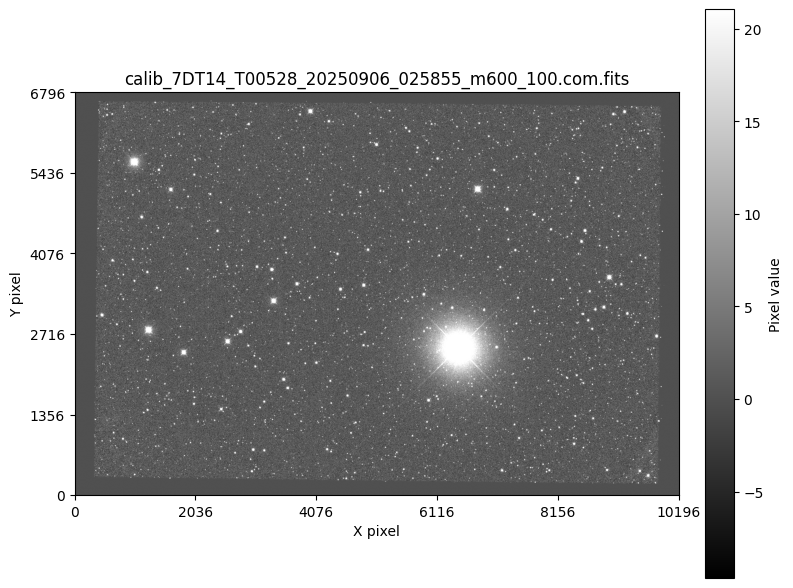

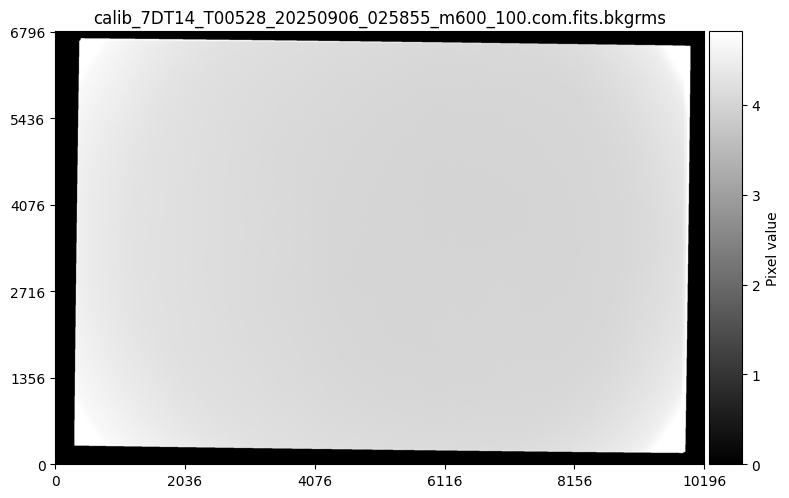

In [21]:
stacked_img.show()
stacked_bkgrms.show()

<br><br>

### 4.3. Image stacking with convolution or ZP scaling 
When images have information about PSF size or zeropoints in the header, you can stack images with convolution or ZP scaling. 

To update the header, please refer Example `Photometric Calibration`.

You can apply FWHM matching and ZP matching after running photometric_calibration process. 

In [22]:
for target_img in target_imglist:
    print("ZP of ", target_img.path.name, ":", target_img.header['ZP_APER_1']) 

ZP of  calib_7DT14_T00528_20250906_025855_m600_100.fits : 26.302696857378585
ZP of  calib_7DT14_T00528_20250903_234441_m600_100.fits : 26.21969918892981
ZP of  calib_7DT14_T00528_20250902_072423_m600_100.fits : 26.24222441668575
ZP of  calib_7DT14_T00528_20250831_235542_m600_100.fits : 26.20522598075139
ZP of  calib_7DT14_T00528_20250902_074036_m600_100.fits : 26.213725328142672
ZP of  calib_7DT14_T00528_20250903_235531_m600_100.fits : 26.270388015374934
ZP of  calib_7DT14_T00528_20250904_234659_m600_100.fits : 26.30584164781407
ZP of  calib_7DT14_T00528_20250902_073848_m600_100.fits : 26.242540486447524
ZP of  calib_7DT14_T00528_20250906_235138_m600_100.fits : 26.295210312679732
ZP of  calib_7DT14_T00528_20250903_235006_m600_100.fits : 26.258317512974056
ZP of  calib_7DT14_T00528_20250820_014852_m600_100.fits : 26.11652441668575
ZP of  calib_7DT14_T00528_20250906_025519_m600_100.fits : 26.230477911415278
ZP of  calib_7DT14_T00528_20250831_233554_m600_100.fits : 26.238168716540233
ZP o

In [23]:
stacked_img, stackged_bkgrms = stacker.stack_multiprocess(
    target_imglist = target_imglist,
    target_bkglist = target_bkglist,
    target_bkgrmslist = target_bkgrmslist,
    n_proc = 16,
    scale = True, # If you want to apply ZP matching, set scale = True
    scale_type = 'min',
    zp_key = 'ZP_APER_1',
    convolve = False, # If you want to apply FWHM matching, set convolve = True
    save = True,
    verbose = False,
)

Combining...: 100%|██████████████████████████████████████████████| 16/16 [04:08]


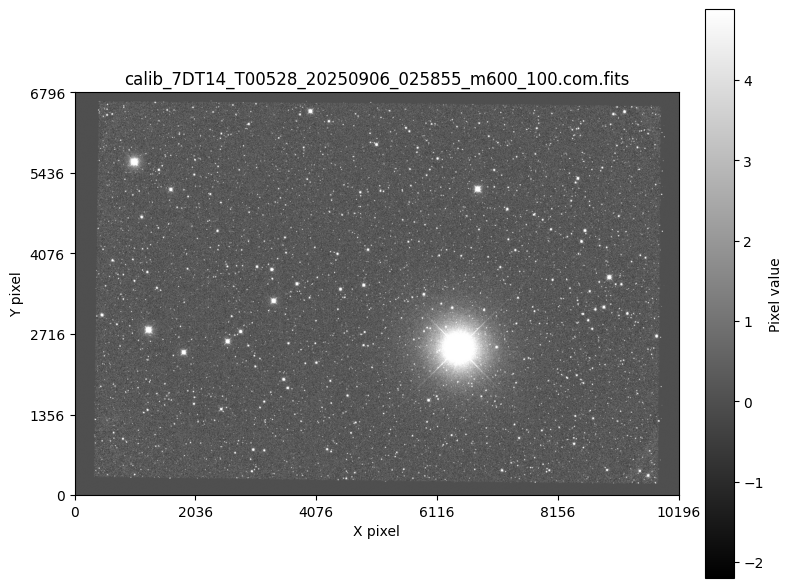

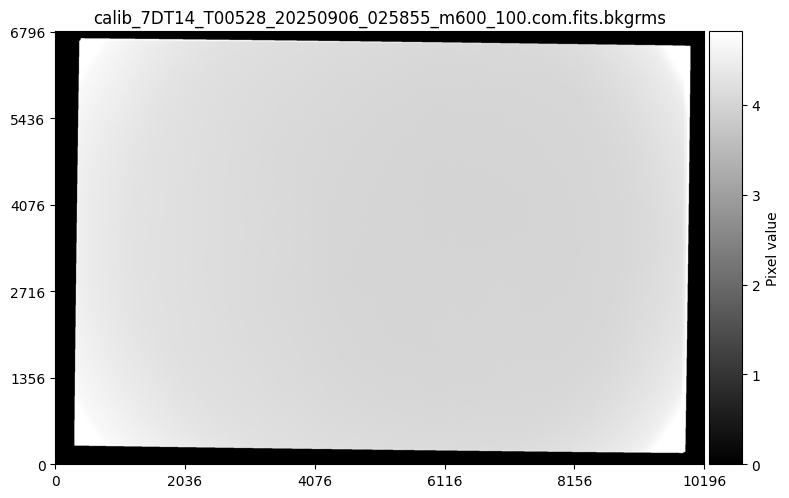

In [24]:
stacked_img.show()
stacked_bkgrms.show()

### 4.4. Image stacking with the selected image

If you wish to select with the absolute criteria 

- Seeing: < 3
- Depth: > 17.0
- Ellipticity: < 0.3

Querying images...: 100%|████████████████████████████████████████| 90/90 [00:00]


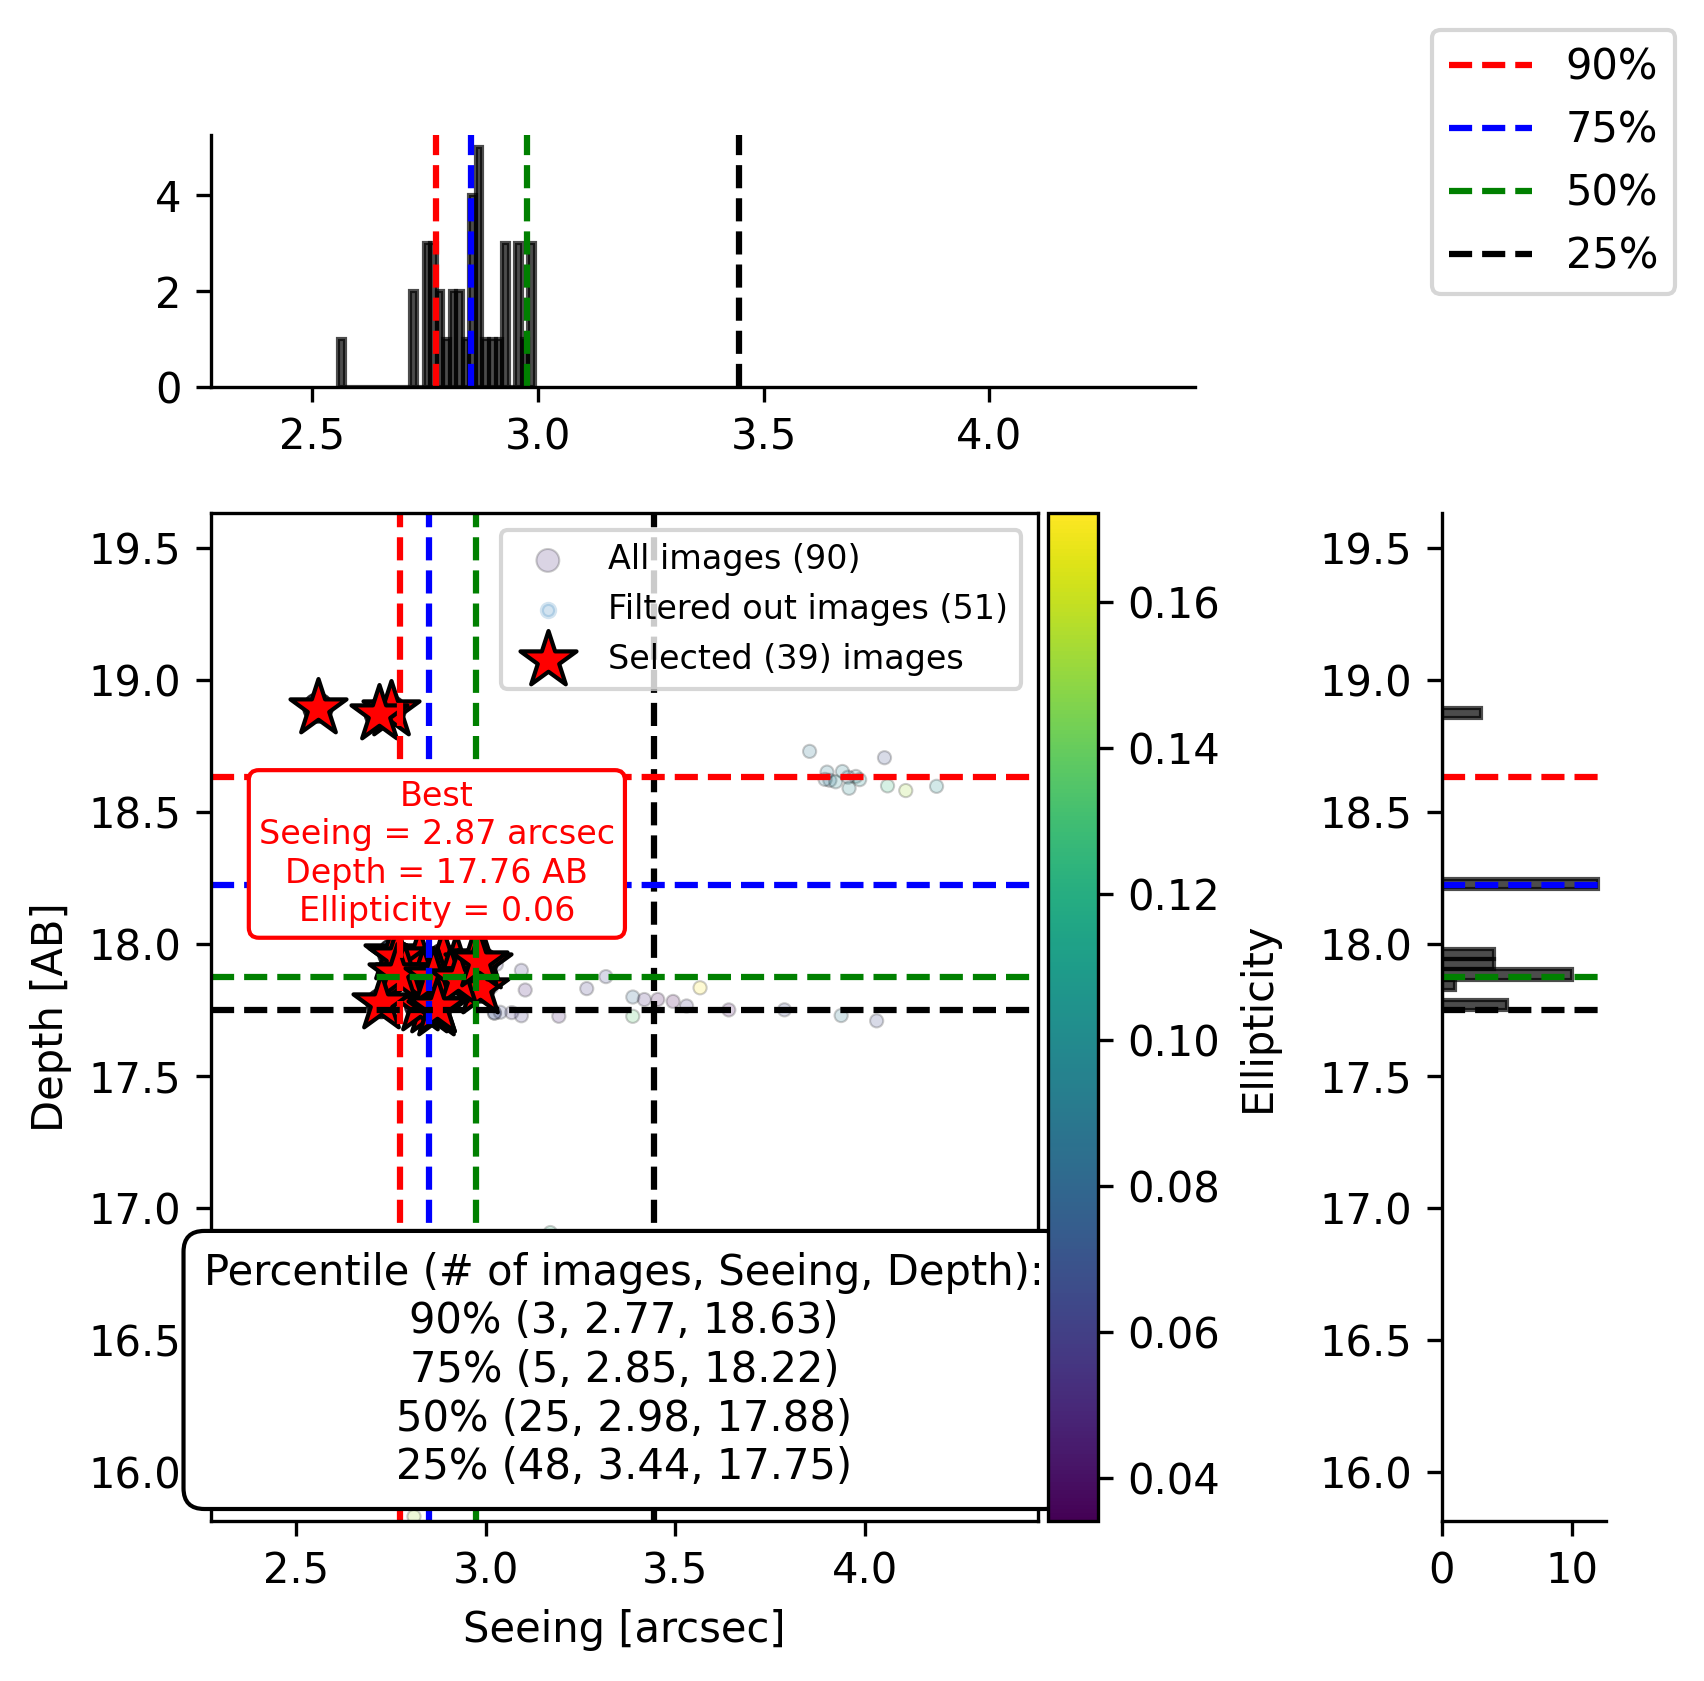

In [25]:

selected_imglist = stacker.select_quality_images(
    target_imglist = target_imglist,
    min_obsdate = None,
    max_obsdate = None,
    seeing_key = 'SEEING',
    depth_key = 'UL5SKY_APER_1',
    ellipticity_key = 'ELLIP',
    obsdate_key = 'DATE-OBS',
    weight_ellipticity = 0.0, # 0.0 means no weight
    weight_seeing = 0.0, # 0.0 means no weight
    weight_depth = 0.0, # 0.0 means no weight
    max_numbers = None, # Set max_nunbers to None to select all images
    seeing_limit = 3.0,
    depth_limit = 17.0,
    ellipticity_limit = 0.3,
    visualize = True,
    verbose = True,
)

If you wish to select top 30 images with the relative weight 
- weight_seeing: 3
- weight_depth: 1
- weight_ellipticity: 2

Querying images...: 100%|████████████████████████████████████████| 90/90 [00:00]


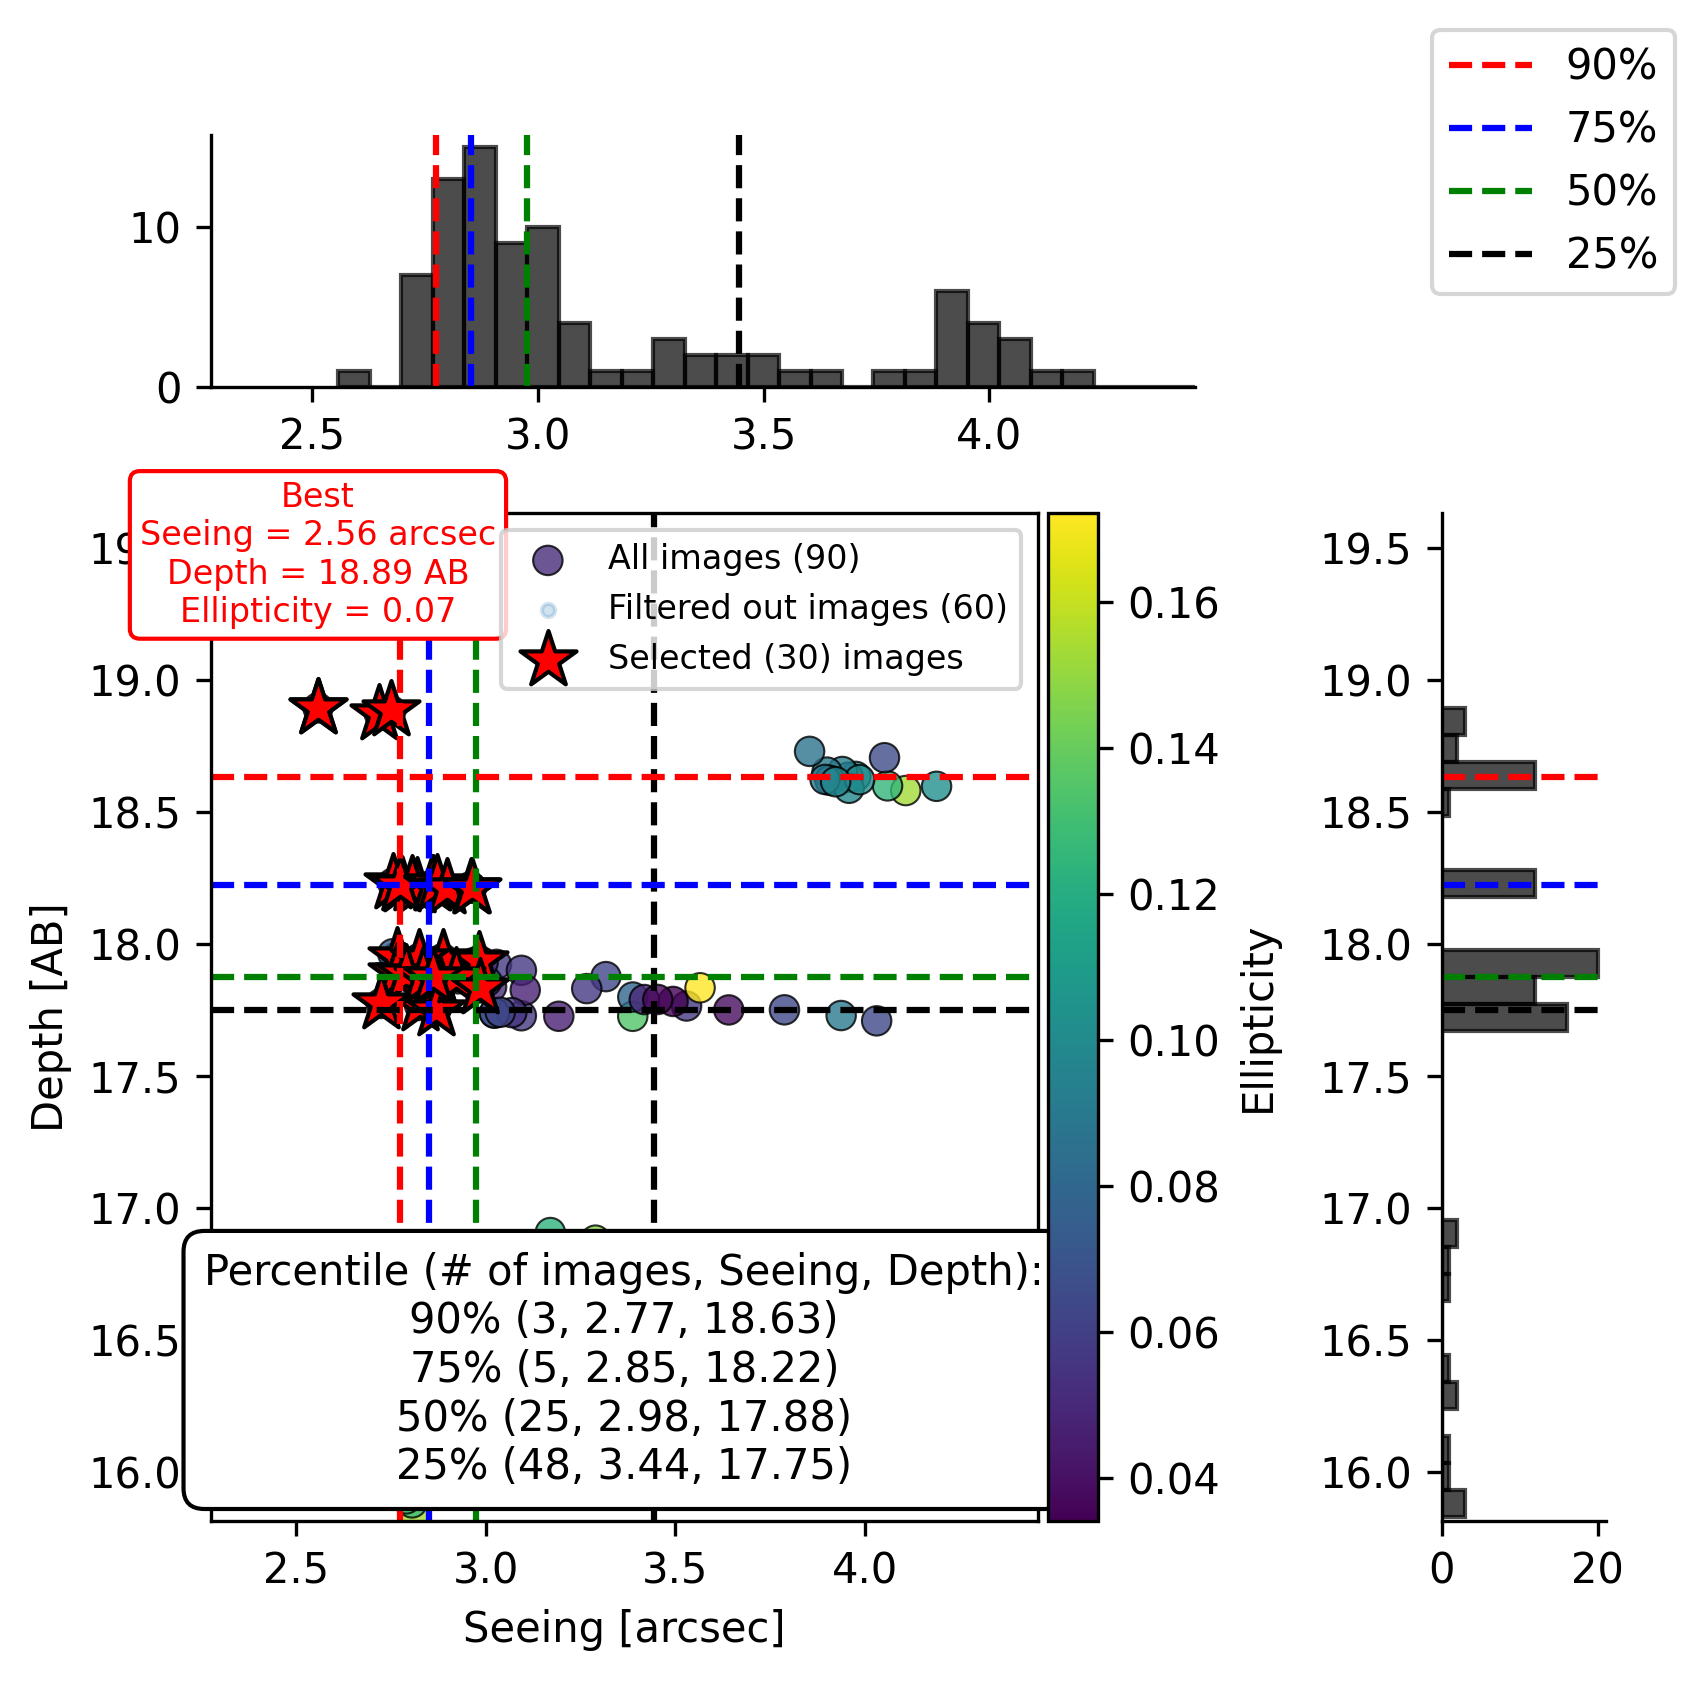

In [26]:

selected_imglist = stacker.select_quality_images(
    target_imglist = target_imglist,
    min_obsdate = None,
    max_obsdate = None,
    seeing_key = 'SEEING',
    depth_key = 'UL5SKY_APER_1',
    ellipticity_key = 'ELLIP',
    obsdate_key = 'DATE-OBS',
    weight_ellipticity = 2.0, 
    weight_seeing = 3.0,
    weight_depth = 1.0, 
    max_numbers = 30,
    seeing_limit = 99,
    depth_limit = 0,
    ellipticity_limit = 1,
    visualize = True,
    verbose = True,
)

In [27]:
from ezphot.imageobjects import ImageSet
selected_imgset = ImageSet(selected_imglist)
selected_imglist = selected_imgset.target_images
selected_bkglist = selected_imgset.bkgmap
selected_bkgrmslist = selected_imgset.bkgrms

Loading bkgrms: 100%|██████████| 30/30 [00:00<00:00, 66.60it/s]


In [30]:
stacked_img_selected, stackged_bkgrms_selected = stacker.stack_multiprocess(
    target_imglist = selected_imglist,
    target_bkglist = selected_bkglist,
    target_bkgrmslist = selected_bkgrmslist,
    n_proc = 16,
    scale = True, # If you want to apply ZP matching, set scale = True
    scale_type = 'min',
    zp_key = 'ZP_APER_1',
    convolve = False, # If you want to apply FWHM matching, set convolve = True
    save = True,
    verbose = False,
)

Combining...: 100%|██████████████████████████████████████████████| 16/16 [01:33]


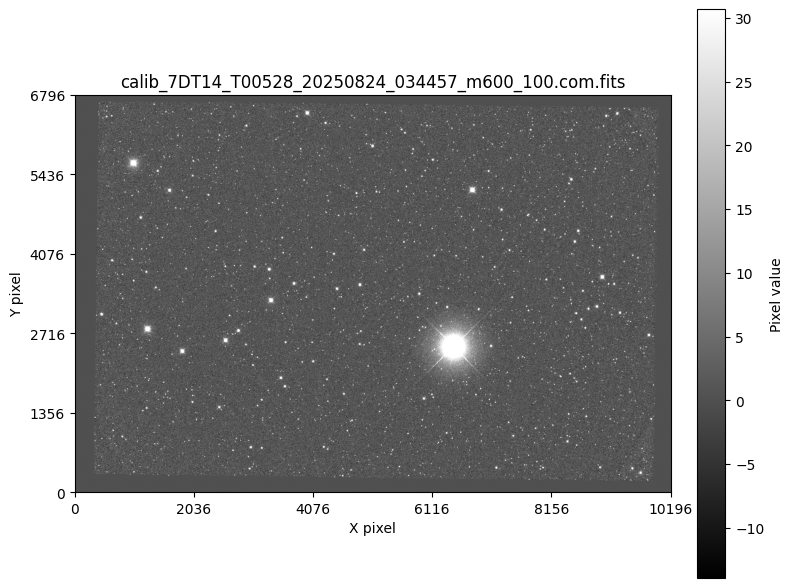

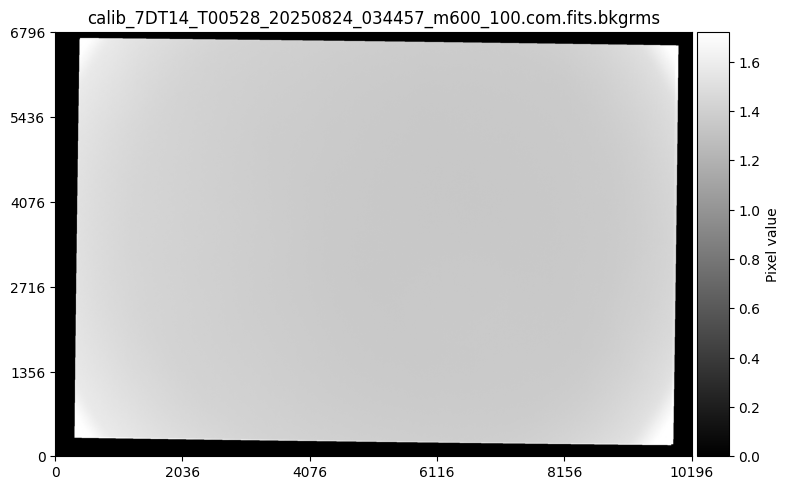

In [33]:
stacked_img_selected.show()
stackged_bkgrms_selected.show()